# Pytorch Introduction with Linear Regression Implementation

In [91]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Linear Regression with Gradient Descent in Numpy

Text(0.5, 1.0, 'train dataset')

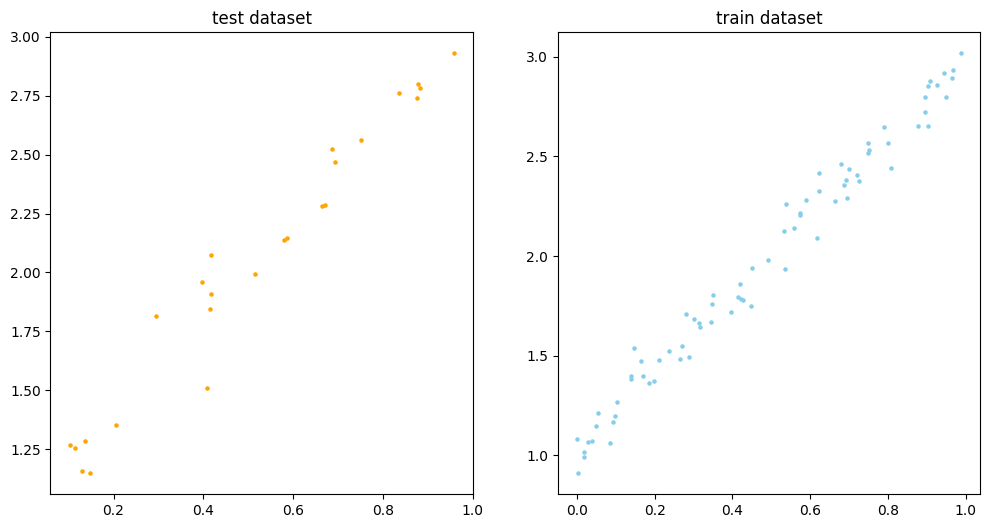

In [92]:
# initialize model
def line(a, b, x):
    return a * x + b

# generate data
np.random.seed(1)
x = 1 * np.random.rand(1000, 1)
y = 2 * x + 1 + 0.1 * np.random.randn(1000, 1)

# generate indices and shuffle them for train/test set
idx = np.arange(100)
np.random.shuffle(idx)

# train/test indices
train_idx = idx[:75]
test_idx = idx[75:]

# create trai/test split
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# plot data
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].set_title("test dataset")
ax[1].set_title("train dataset")

In [93]:
# random slope and intercept
epochs = 100
batch = 5
lr = 1e-1

m = np.random.randn(1)
q = np.random.randn(1)

print("m before training: ", m)
print("q before training: ", q)
print()

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    mse_batch = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))

        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]

        y_pred = line(m, q, x_train_batch)
        error = y_train_batch - y_pred

        mse = error ** 2

        q_grad = -2 * error.mean()
        m_grad = -2 * (x_train_batch * error).mean()

        m = m - m_grad * lr
        q = q - q_grad * lr

        print(f"Loss: {mse.mean()}")
        mse_batch.append(mse)
    train_history.append(np.array(mse_batch).mean())
    print()


print("m after training: ", m)
print("q after training: ", q)
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

m before training:  [-0.2669303]
q before training:  [0.70915717]

Epoch: 1
Batch: 1/5
Loss: 3.0993185609569265
Batch: 2/5
Loss: 1.1501037534377239
Batch: 3/5
Loss: 0.7258726735310412
Batch: 4/5
Loss: 0.37782319343875936
Batch: 5/5
Loss: 0.5463210942812532

Epoch: 2
Batch: 1/5
Loss: 0.4911819131735841
Batch: 2/5
Loss: 0.21956718583154414
Batch: 3/5
Loss: 0.24836540438407043
Batch: 4/5
Loss: 0.15158621670858097
Batch: 5/5
Loss: 0.20640971152752338

Epoch: 3
Batch: 1/5
Loss: 0.2389131836807701
Batch: 2/5
Loss: 0.16503145500854424
Batch: 3/5
Loss: 0.21260391323237154
Batch: 4/5
Loss: 0.13960797419774398
Batch: 5/5
Loss: 0.15043448590668873

Epoch: 4
Batch: 1/5
Loss: 0.18322392895101686
Batch: 2/5
Loss: 0.14580474448533284
Batch: 3/5
Loss: 0.18841345525691217
Batch: 4/5
Loss: 0.1256788992700237
Batch: 5/5
Loss: 0.1256247126550986

Epoch: 5
Batch: 1/5
Loss: 0.1553300117437364
Batch: 2/5
Loss: 0.12754659936147134
Batch: 3/5
Loss: 0.16466331941108409
Batch: 4/5
Loss: 0.11032274278045848
Batch

Text(0.5, 1.0, 'train loss')

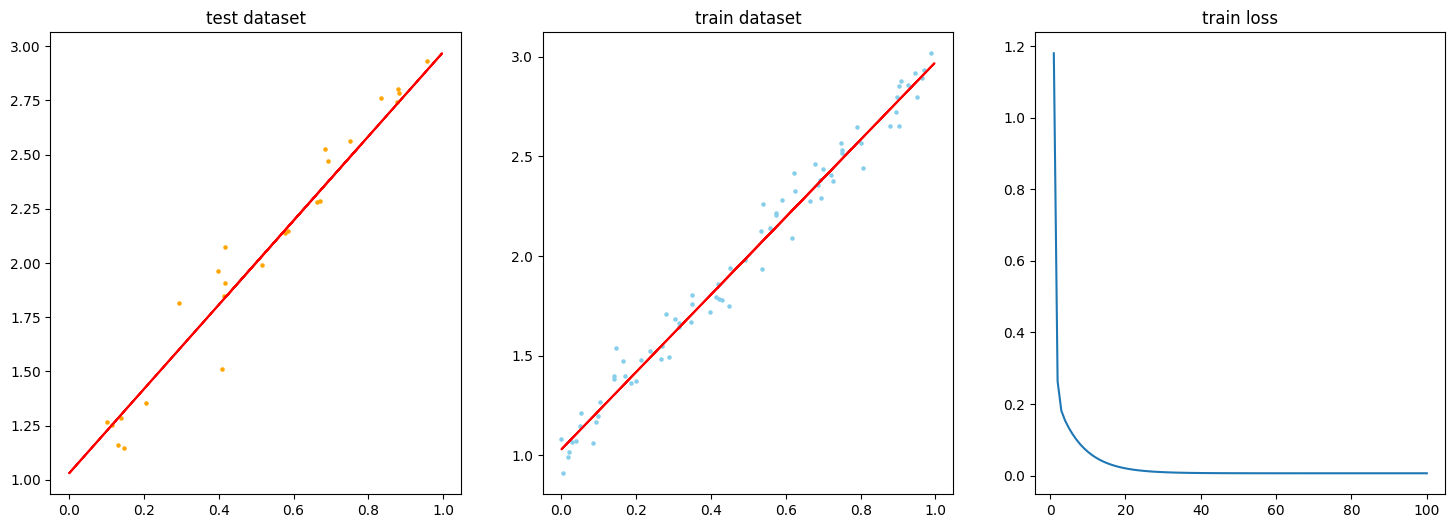

In [94]:
# use learned coeff
y_pred = line(m, q, x)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x, y_pred, c="red")
ax[1].plot(x, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

## 2. Optimize Linear Regression with PyTorch

### 2.1 Autograd and Computational Graph

In [95]:
import torch
import torch.optim as optim
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

In [96]:
# convert data into tensors
x_tensor = torch.from_numpy(x).float().to(device)
y_tensor = torch.from_numpy(y).float().to(device)

print(type(x))
print(type(x_tensor))
print(x_tensor.type())

# index for train/test split
idx = torch.arange(0, 100)
perm = torch.randperm(idx.shape[0])
idx = idx[perm]

idx_train = idx[:75]
idx_test = idx[75:]

x_train, y_train = x_tensor[idx_train], y_tensor[idx_train]
x_test, y_test = x_tensor[idx_test], y_tensor[idx_test]

<class 'numpy.ndarray'>
<class 'torch.Tensor'>
torch.FloatTensor


In [97]:
epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
m = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
q = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

print("m before training: ", m)
print("q before training: ", q)
print()

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    batch_loss = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))
        
        # calculate prediction
        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]
        y_pred = m * x_train_batch + q

        # calculate loss
        print(x_train_batch.shape)
        print(y_pred.shape)
        error = y_train_batch - y_pred
        loss = (error**2).mean()
        batch_loss.append(loss.item())

        # calculate gradient
        loss.backward()

        print(m_grad)
        print(q_grad)

        with torch.no_grad():
            m -= lr*m.grad
            q -= lr*q.grad

        m.grad.zero_()
        q.grad.zero_()
    train_history.append(np.array(batch_loss).mean())

print()
print("m after training: ", m)
print("q after training: ", q)
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

m before training:  tensor([0.6614], requires_grad=True)
q before training:  tensor([0.2669], requires_grad=True)

Epoch: 1
Batch: 1/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 2/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 3/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 4/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 5/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Epoch: 2
Batch: 1/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 2/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 3/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 4/5
torch.Size([15, 1])
torch.Size([15, 1])
0.012788368715656664
0.01642654445276103
Batch: 5/5
torch.Size([15, 1])
torch.Si

Text(0.5, 1.0, 'train loss')

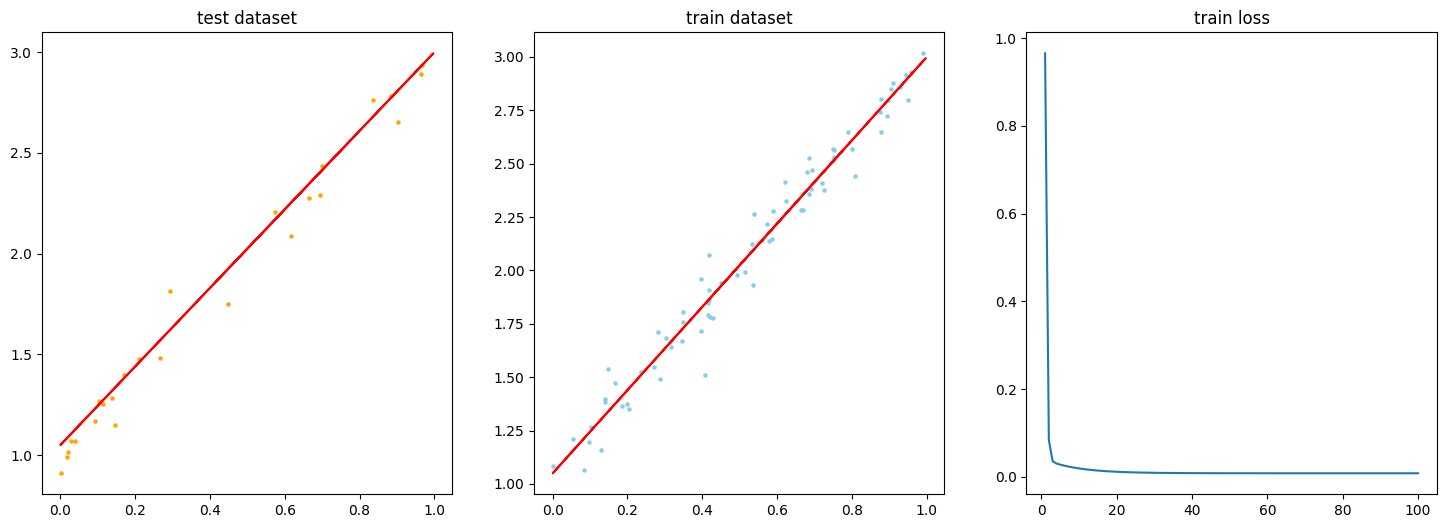

In [98]:
# use learned coeff
y_pred = line(m.detach(), q.detach(), x_tensor)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_tensor, y_pred, c="red")
ax[1].plot(x_tensor, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

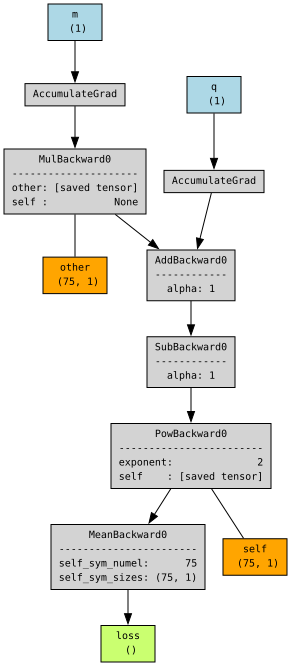

In [99]:
# visualize gradient computational graph 
import torchviz as tv
y_hat = m * x_train + q
error = y_train - y_hat
loss = (error**2).mean()


tv.make_dot(loss, params={"m": m, "q": q, "loss": loss}, show_attrs=True, show_saved=True)

### 2.2 Optimizer

In [100]:
epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
m = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
q = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

# define an optimizer
optimizer = optim.SGD([m, q], lr=lr)

print("m before training: ", m)
print("q before training: ", q)
print()

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    batch_loss = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))
        
        # calculate prediction
        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]
        y_pred = m * x_train_batch + q

        # calculate loss
        error = y_train_batch - y_pred
        loss = (error**2).mean()
        batch_loss.append(loss.item())

        # calculate gradient
        loss.backward()
        optimizer.step()

        optimizer.zero_grad()
    batch_mean_loss = np.array(batch_loss).mean()
    train_history.append(batch_mean_loss)
    print(f"loss: {batch_mean_loss}")
    print()

print()
print("m after training: ", m)
print("q after training: ", q)
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

m before training:  tensor([0.6614], requires_grad=True)
q before training:  tensor([0.2669], requires_grad=True)

Epoch: 1
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.9651016920804978

Epoch: 2
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.08441276103258133

Epoch: 3
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.03571872562170029

Epoch: 4
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.030550669878721237

Epoch: 5
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02797728106379509

Epoch: 6
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02580229379236698

Epoch: 7
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.023873912543058394

Epoch: 8
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.022157691046595575

Epoch: 9
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02062965780496597

Epoch: 10
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5

Text(0.5, 1.0, 'train loss')

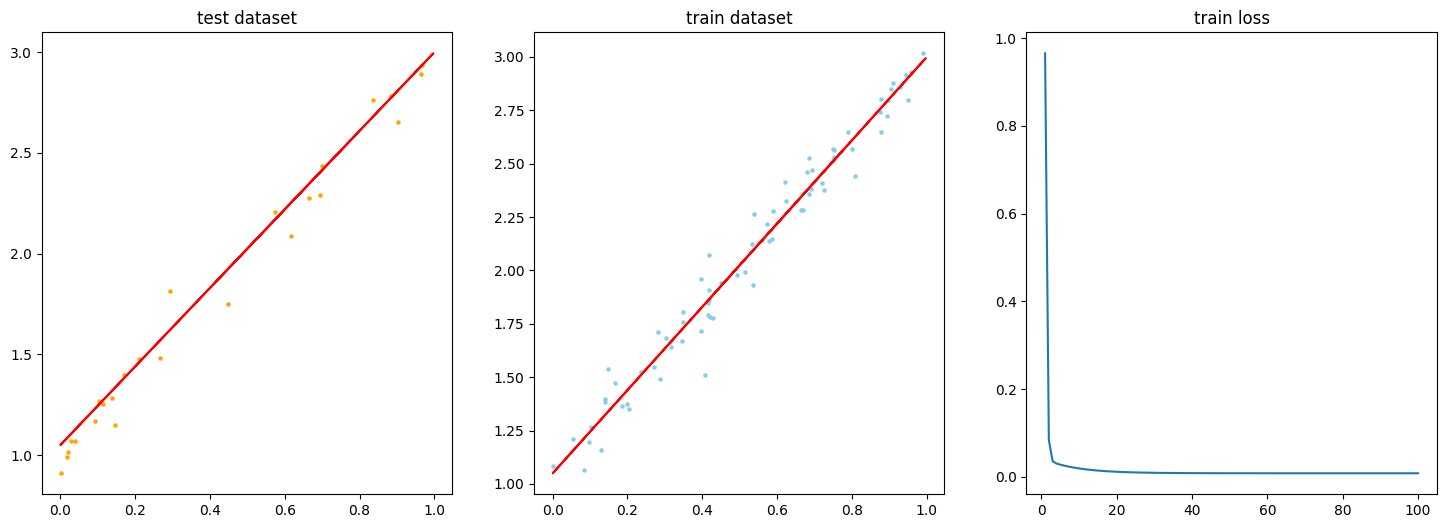

In [101]:
# use learned coeff
y_pred = line(m.detach(), q.detach(), x_tensor)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_tensor, y_pred, c="red")
ax[1].plot(x_tensor, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

### 2.3 Loss

In [102]:
epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
m = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)
q = torch.randn(1, requires_grad=True, dtype=torch.float, device=device)

# define an optimizer
optimizer = optim.SGD([m, q], lr=lr)

# define loss function
loss_fn = nn.MSELoss(reduction="mean")

print("m before training: ", m)
print("q before training: ", q)
print()

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    batch_loss = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))
        
        # calculate prediction
        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]
        y_pred = m * x_train_batch + q

        # calculate loss
        loss = loss_fn(y_train_batch, y_pred)
        batch_loss.append(loss.item())

        # calculate gradient
        loss.backward()
        optimizer.step()

        optimizer.zero_grad()
    batch_mean_loss = np.array(batch_loss).mean()
    train_history.append(batch_mean_loss)
    print(f"loss: {batch_mean_loss}")
    print()

print()
print("m after training: ", m)
print("q after training: ", q)
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

m before training:  tensor([0.6614], requires_grad=True)
q before training:  tensor([0.2669], requires_grad=True)

Epoch: 1
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.9651016920804978

Epoch: 2
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.08441276103258133

Epoch: 3
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.03571872562170029

Epoch: 4
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.030550669878721237

Epoch: 5
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02797728106379509

Epoch: 6
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02580229379236698

Epoch: 7
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.023873912543058394

Epoch: 8
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.022157691046595575

Epoch: 9
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02062965780496597

Epoch: 10
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5

Text(0.5, 1.0, 'train loss')

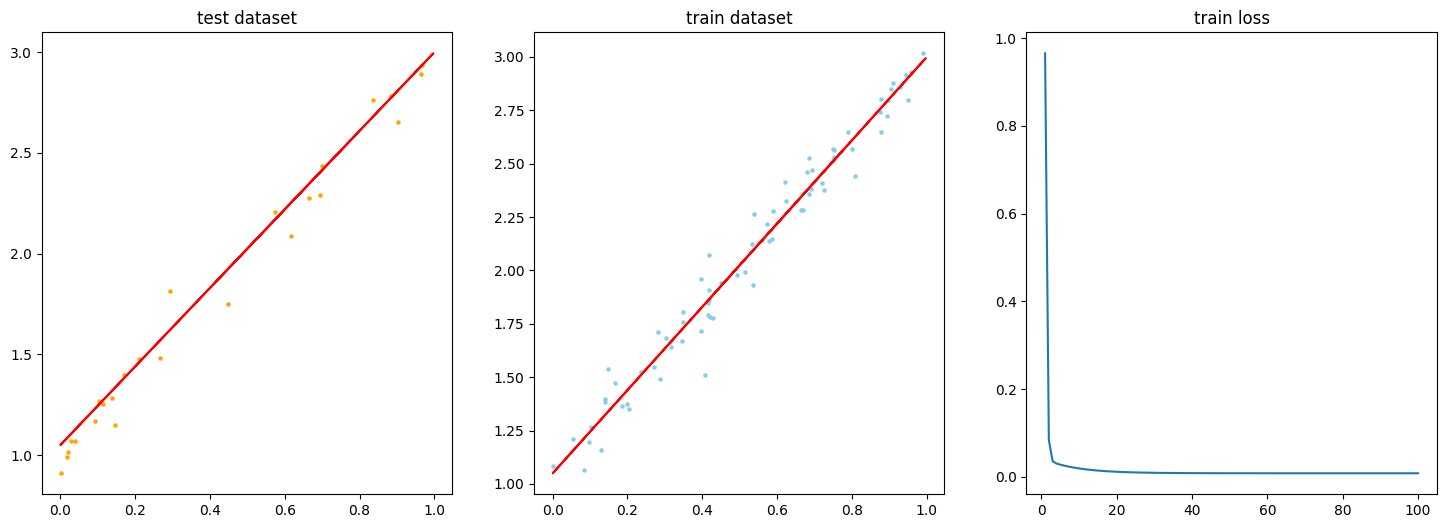

In [103]:
# use learned coeff
y_pred = line(m.detach(), q.detach(), x_tensor)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_tensor, y_pred, c="red")
ax[1].plot(x_tensor, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

### 2.4 Model

In [104]:
# define Model
class ManualLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.m = nn.Parameter(torch.randn(1, dtype=torch.float))
        self.q = nn.Parameter(torch.randn(1, dtype=torch.float))
    
    def forward(self, x):
        return self.m * x + self.q

In [105]:
epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
model = ManualLinearRegression().to(device)

print(model.state_dict())

# define an optimizer
optimizer = optim.SGD(model.parameters(), lr=lr)

# define loss function
loss_fn = nn.MSELoss(reduction="mean")

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    batch_loss = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))
        
        # calculate prediction
        model.train()
        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]
        y_pred = model(x_train_batch)
        # calculate loss
        loss = loss_fn(y_train_batch, y_pred)
        batch_loss.append(loss.item())

        # calculate gradient
        loss.backward()
        optimizer.step()

        optimizer.zero_grad()
    batch_mean_loss = np.array(batch_loss).mean()
    train_history.append(batch_mean_loss)
    print(f"loss: {batch_mean_loss}")
    print()

print()
print(model.state_dict())
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

OrderedDict({'m': tensor([0.6614]), 'q': tensor([0.2669])})
Epoch: 1
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.9651016920804978

Epoch: 2
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.08441276103258133

Epoch: 3
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.03571872562170029

Epoch: 4
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.030550669878721237

Epoch: 5
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02797728106379509

Epoch: 6
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02580229379236698

Epoch: 7
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.023873912543058394

Epoch: 8
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.022157691046595575

Epoch: 9
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02062965780496597

Epoch: 10
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.019269071891903876

Epoch: 11
Batch: 1/5
Batch

Text(0.5, 1.0, 'train loss')

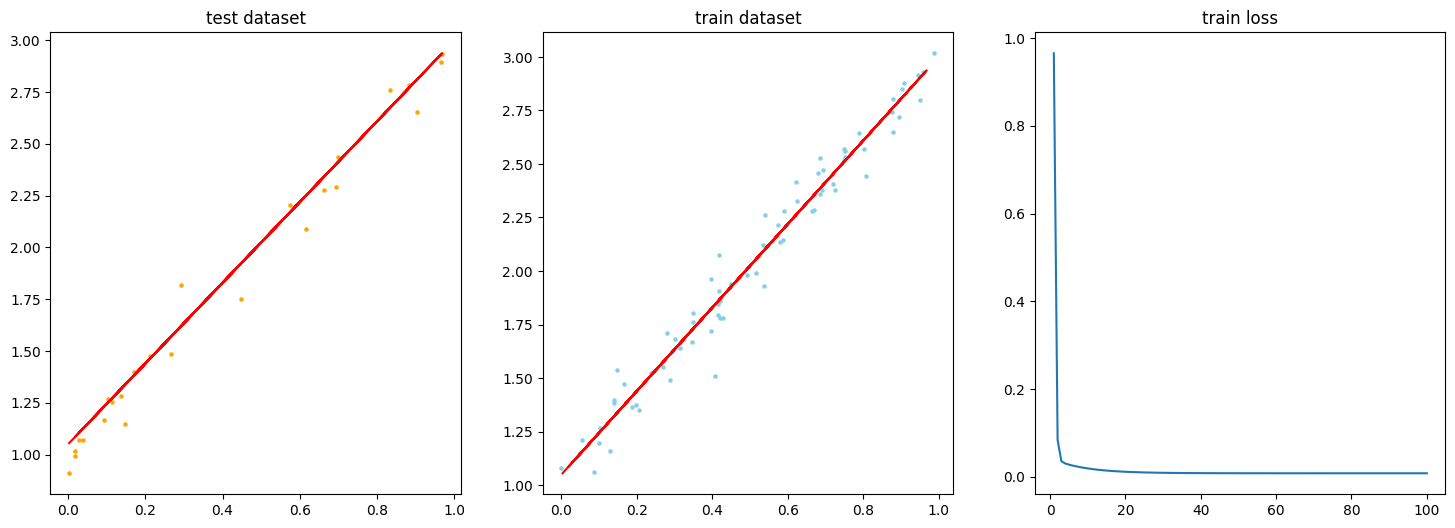

In [106]:
# use learned coeff
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_test, y_pred, c="red")
ax[1].plot(x_test, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

### 2.5 Nested Models

In [107]:
# define Model
class ManualLinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(1, 1)
    
    def forward(self, x):
        return self.linear(x)

In [108]:
epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
model = ManualLinearRegression().to(device)

print(model.state_dict())

# define an optimizer
optimizer = optim.SGD(model.parameters(), lr=lr)

# define loss function
loss_fn = nn.MSELoss(reduction="mean")

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    batch_loss = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))
        
        # calculate prediction
        model.train()
        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]
        y_pred = model(x_train_batch)
        # calculate loss
        loss = loss_fn(y_train_batch, y_pred)
        batch_loss.append(loss.item())

        # calculate gradient
        loss.backward()
        optimizer.step()

        optimizer.zero_grad()
    batch_mean_loss = np.array(batch_loss).mean()
    train_history.append(batch_mean_loss)
    print(f"loss: {batch_mean_loss}")
    print()

print()
print(model.state_dict())
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

OrderedDict({'linear.weight': tensor([[0.5153]]), 'linear.bias': tensor([-0.4414])})
Epoch: 1
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 2.1907001376152038

Epoch: 2
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.13432261496782302

Epoch: 3
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.02673659771680832

Epoch: 4
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.019849759712815284

Epoch: 5
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.018320944160223007

Epoch: 6
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.017200077325105666

Epoch: 7
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.016214681044220924

Epoch: 8
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.015337861515581608

Epoch: 9
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.014557112008333206

Epoch: 10
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.013861894421279431

Text(0.5, 1.0, 'train loss')

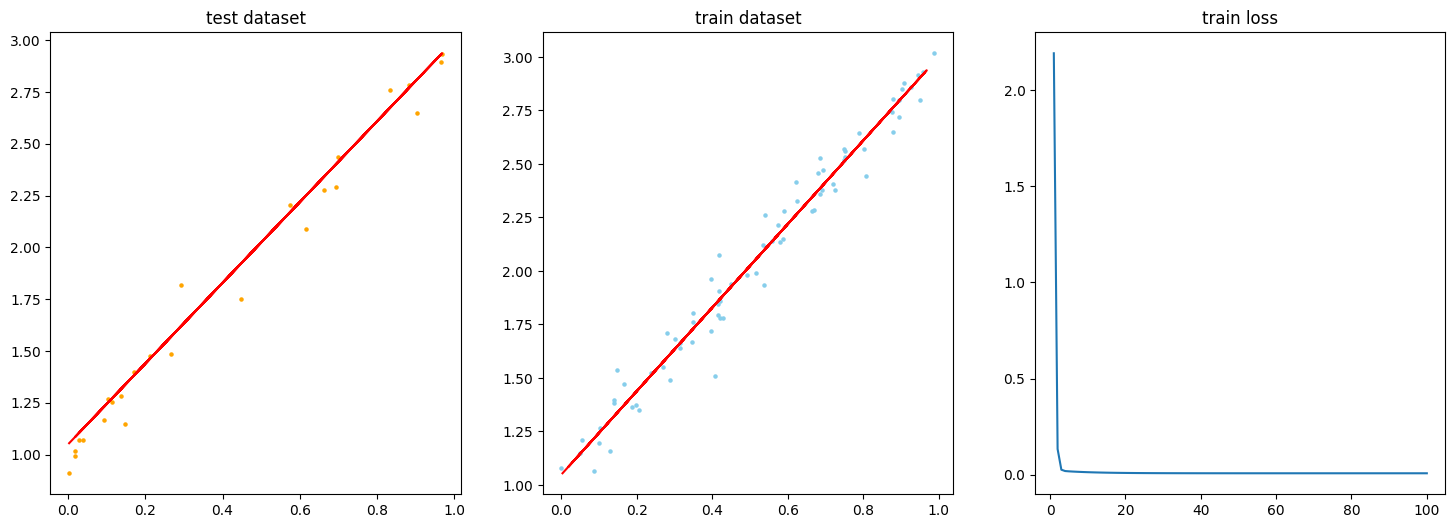

In [109]:
# use learned coeff
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_test, y_pred, c="red")
ax[1].plot(x_test, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

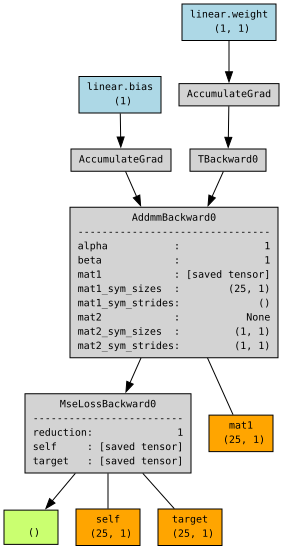

In [110]:
# visualize gradient computational graph
y_pred = model(x_test)
loss = loss_fn(y_test, y_pred)
tv.make_dot(loss, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)

### 2.6 Sequential Models

In [111]:
epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
model = nn.Sequential(
    nn.Linear(1, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

print(model.state_dict())

# define an optimizer
optimizer = optim.SGD(model.parameters(), lr=lr)

# define loss function
loss_fn = nn.MSELoss(reduction="mean")

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    batch_loss = []
    for b in range(batch):
        print(f"Batch: {b+1}/{batch}")
        batch_idx = int(len(x_train)/batch*b)
        batch_idx_1 = int(len(x_train)/batch*(b+1))
        
        # calculate prediction
        model.train()
        x_train_batch = x_train[batch_idx:batch_idx_1]
        y_train_batch = y_train[batch_idx:batch_idx_1]
        y_pred = model(x_train_batch)
        # calculate loss
        loss = loss_fn(y_train_batch, y_pred)
        batch_loss.append(loss.item())

        # calculate gradient
        loss.backward()
        optimizer.step()

        optimizer.zero_grad()
    batch_mean_loss = np.array(batch_loss).mean()
    train_history.append(batch_mean_loss)
    print(f"loss: {batch_mean_loss}")
    print()

print()
print(model.state_dict())
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

OrderedDict({'0.weight': tensor([[ 0.5153],
        [-0.4414],
        [-0.1939],
        [ 0.4694],
        [-0.9414]]), '0.bias': tensor([ 0.5997, -0.2057,  0.5087,  0.1390, -0.1224]), '2.weight': tensor([[ 0.1240,  0.0221,  0.1633, -0.1743, -0.0326]]), '2.bias': tensor([-0.0403])})
Epoch: 1
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 1.2929465159773827

Epoch: 2
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.13584581166505813

Epoch: 3
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.11463393419981002

Epoch: 4
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.09614674597978592

Epoch: 5
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.08011015579104423

Epoch: 6
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.06633836105465889

Epoch: 7
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.0546638123691082

Epoch: 8
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
loss: 0.0449129

Text(0.5, 1.0, 'train loss')

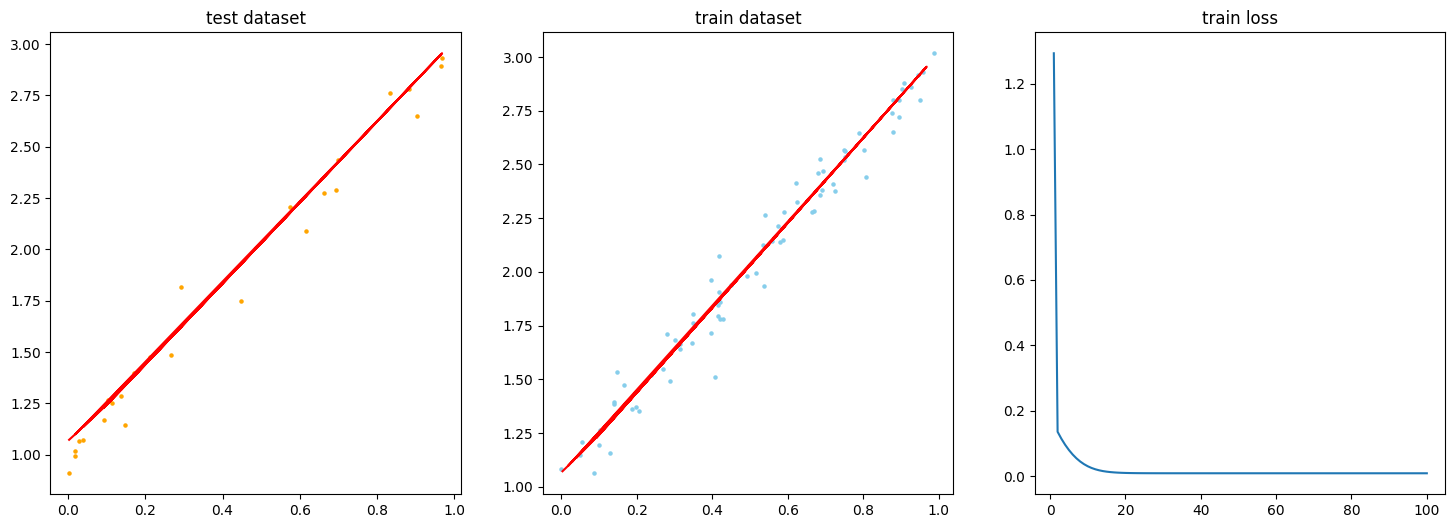

In [112]:
# use learned coeff
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_test, y_pred, c="red")
ax[1].plot(x_test, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")

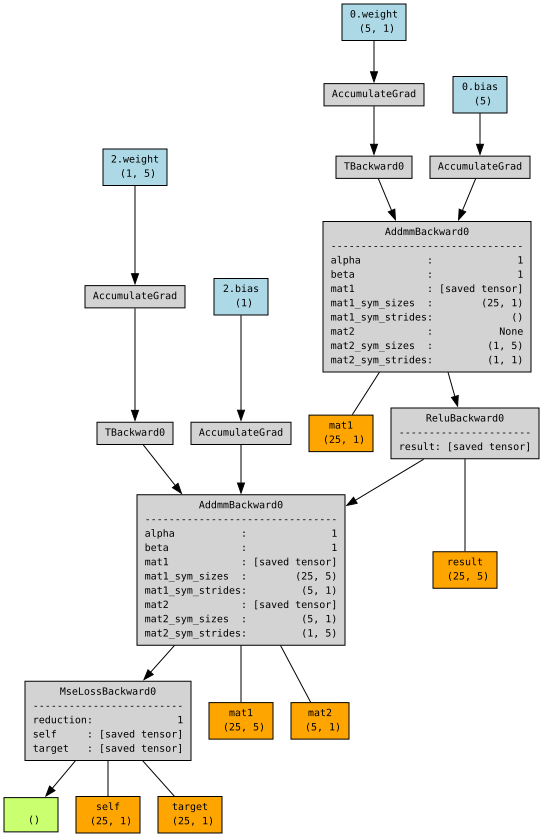

In [113]:
# visualize gradient computational graph
y_pred = model(x_test)
loss = loss_fn(y_test, y_pred)
tv.make_dot(loss, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)

### 2.7 Training Structure

In [114]:
# generic function for making a train step 
def make_train_step(model, optimizer, loss):
    # training function that gets created
    def train_step(x, y, batch_size):
        batch_loss = []
        # creates batches
        for b in range(batch):
            print(f"Batch: {b+1}/{batch}")
            batch_idx = int(len(x_train)/batch*b)
            batch_idx_1 = int(len(x_train)/batch*(b+1))
        
            # calculate prediction
            model.train()
            x_train_batch = x_train[batch_idx:batch_idx_1]
            y_train_batch = y_train[batch_idx:batch_idx_1]
            y_pred = model(x_train_batch)
            # calculate loss
            loss = loss_fn(y_train_batch, y_pred)
            batch_loss.append(loss.item())

            # calculate gradient
            loss.backward()
            optimizer.step()

            optimizer.zero_grad()
        batch_mean_loss = np.array(batch_loss).mean()
        return batch_mean_loss
    
    return train_step


epochs = 100
batch = 5
lr = 1e-1

# create trainable parameters
torch.manual_seed(1)
model = nn.Sequential(
    nn.Linear(1, 5),
    nn.ReLU(),
    nn.Linear(5, 1)
)

print(model.state_dict())

# define an optimizer
optimizer = optim.SGD(model.parameters(), lr=lr)

# define loss function
loss_fn = nn.MSELoss(reduction="mean")

# create training function
training_step = make_train_step(model, optimizer, loss_fn)

train_history = []
for e in range(epochs):
    print(f"Epoch: {e+1}")
    # perform a train step
    loss = training_step(x_train, y_train, batch)
    train_history.append(loss)

print()
print(model.state_dict())
print()

# just to see if implementation correct
from sklearn.linear_model import LinearRegression
linr = LinearRegression()
linr.fit(x_train, y_train)
print(linr.intercept_, linr.coef_[0])

OrderedDict({'0.weight': tensor([[ 0.5153],
        [-0.4414],
        [-0.1939],
        [ 0.4694],
        [-0.9414]]), '0.bias': tensor([ 0.5997, -0.2057,  0.5087,  0.1390, -0.1224]), '2.weight': tensor([[ 0.1240,  0.0221,  0.1633, -0.1743, -0.0326]]), '2.bias': tensor([-0.0403])})
Epoch: 1
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 2
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 3
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 4
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 5
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 6
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 7
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 8
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 9
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 10
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 11
Batch: 1/5
Batch: 2/5
Batch: 3/5
Batch: 4/5
Batch: 5/5
Epoch: 1

Text(0.5, 1.0, 'train loss')

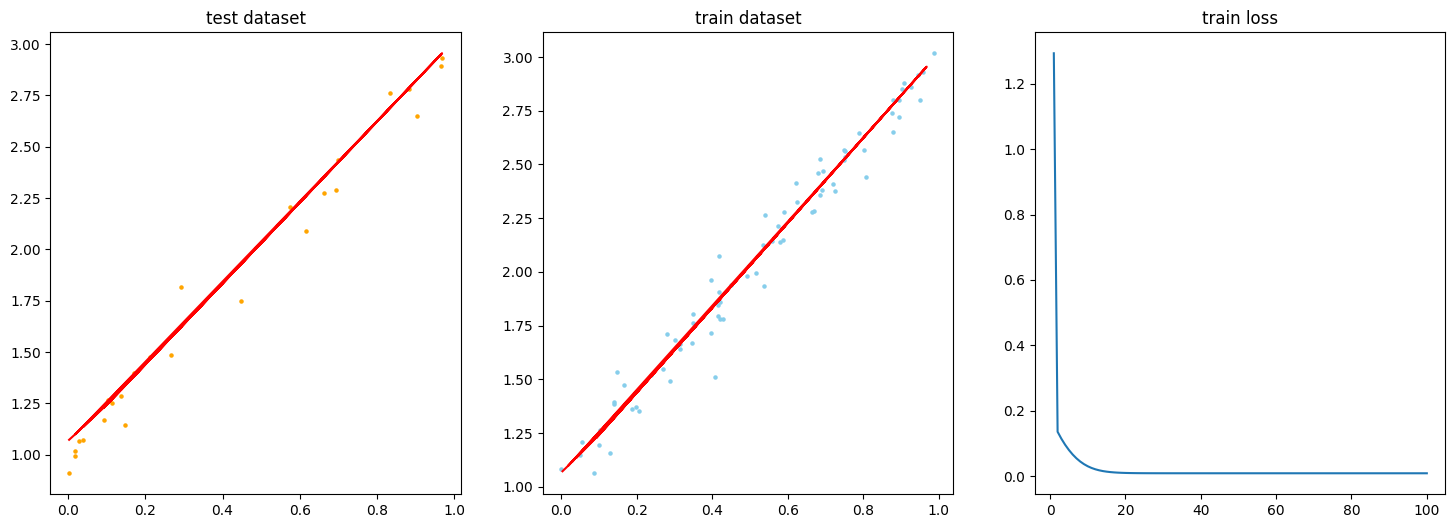

In [115]:
# use learned coeff
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

# plot data
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].scatter(x_test, y_test, s=5, c="orange")
ax[1].scatter(x_train, y_train, s=5, c="skyblue")
ax[0].plot(x_test, y_pred, c="red")
ax[1].plot(x_test, y_pred, c="red")
ax[2].plot(range(1, epochs+1), train_history)

ax[0].set_title("test dataset")
ax[1].set_title("train dataset")
ax[2].set_title("train loss")